### Objective

#### Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, recall_score
from sklearn.base import clone


#remove outliers (maybe)
#nested cross validation 

#### Load preprocessed data

In [251]:
#Load the dataset
project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data
from src.preprocessing import das28_change

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=pd.read_pickle('data_cleaned.pkl')

#### Initial checks of the modeling dataset

In [252]:
df_cleaned.shape

(393, 55)

In [253]:
# Examine visit intervals and timeframes
print("Visit intervals between consecutive visits:")
df_sorted = df_cleaned.sort_values(['patient_id', 'visit_date'])
df_sorted['days_to_next_visit'] = df_sorted.groupby('patient_id')['visit_date'].diff().dt.days

print(f"Mean days between visits: {df_sorted['days_to_next_visit'].mean():.1f}")
print(f"Median days between visits: {df_sorted['days_to_next_visit'].median():.1f}")
print(f"Min: {df_sorted['days_to_next_visit'].min():.0f}, Max: {df_sorted['days_to_next_visit'].max():.0f}")
print(f"\nDistribution of days to next visit:")
print(df_sorted['days_to_next_visit'].describe())


Visit intervals between consecutive visits:
Mean days between visits: 234.3
Median days between visits: 181.0
Min: 14, Max: 1293

Distribution of days to next visit:
count     287.000000
mean      234.344948
std       191.733962
min        14.000000
25%       105.000000
50%       181.000000
75%       296.500000
max      1293.000000
Name: days_to_next_visit, dtype: float64


In [254]:
# Stratify by visit interval
print("\nBreakdown by visit interval:")
print(f"Visits <6 months (180 days): {(df_sorted['days_to_next_visit'] < 180).sum()} ({(df_sorted['days_to_next_visit'] < 180).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits 6-12 months (180-365 days): {((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()} ({((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits >12 months: {(df_sorted['days_to_next_visit'] >= 365).sum()} ({(df_sorted['days_to_next_visit'] >= 365).sum()/len(df_sorted)*100:.1f}%)")

# Check flare rates by interval
print("\nFlare rates by visit interval:")
df_sorted['visit_interval'] = pd.cut(df_sorted['days_to_next_visit'], 
                                       bins=[0, 180, 365, 2000], 
                                       labels=['<6mo', '6-12mo', '>12mo'])
print(df_sorted.groupby('visit_interval')['flare_next_visit'].agg(['count', 'sum', 'mean']))


Breakdown by visit interval:
Visits <6 months (180 days): 142 (36.1%)
Visits 6-12 months (180-365 days): 94 (23.9%)
Visits >12 months: 51 (13.0%)

Flare rates by visit interval:
                count  sum      mean
visit_interval                      
<6mo              142   45  0.316901
6-12mo             94   28  0.297872
>12mo              51   16  0.313725


In [255]:
# Statistical test for flare rate differences by visit interval
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df_sorted['visit_interval'], df_sorted['flare_next_visit'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for independence:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion: Flare rates {'DO NOT' if p_value > 0.05 else 'DO'} differ significantly across visit intervals (α=0.05)")

Chi-square test for independence:
Chi-square statistic: 0.0995
p-value: 0.9515
Degrees of freedom: 2

Conclusion: Flare rates DO NOT differ significantly across visit intervals (α=0.05)


#### Target Variable Definition
Our prediction target is **"flare occurrence at the patient's next scheduled visit"**, defined as a clinical flare in disease activity occurring between the index visit and the next follow-up visit. 

**Temporal characteristics:**
- Median follow-up interval: 181 days (6 months)
- IQR: 105-296 days
- Range: 14-1293 days

**Flare rates by follow-up interval:**
- <6 months (n=142): 31.7%
- 6-12 months (n=94): 29.8%
- >12 months (n=51): 31.4%

The consistency of flare rates across different visit intervals (p-value suggests no significant difference) validates our modeling approach, as it indicates that disease activity flares occur at relatively stable rates regardless of follow-up timing.


#### Define target, groups, and candidate features

In [256]:
# # Calculate das28_change before defining features
# # This uses df_cleaned while it still has patient_id for the groupby operation
# df_cleaned['das28_change'] = df_cleaned.groupby('patient_id')['das28_score'].diff()

# # Set first visit for each patient to 0 (no previous visit to compare)
# first_visit_idx = df_cleaned.groupby('patient_id').head(1).index
# df_cleaned.loc[first_visit_idx, 'das28_change'] = 0


In [ ]:
#Define the target variable
target_variable = 'flare_next_visit'

#Drop the columns that are not needed for modeling plus the target variable, after EDA analysis.

drop_columns = [
    target_variable,
    'das28_change',
    'flare_event',
    # 'patient_id',
    'visit_date', 
    'source',
    'year_of_diagnosis',
    'crp_normalized',
    'crp_upper_limit',
    'crp',
    'esr',
    'mtx_use',
    'steroid_use',
    'mtx_dose_category',
    'steroid_dose_category',
    'comorbidities',
    'csdmard_name',
    'b_ts_dmard_name', 
    'switch_reason', 
    'treatment_decision',
    'birth_year',
    'das28_bins',
    'visit_type',
    'disease_duration',
    'comorb_renal_urological',
    'comorb_malignancy',
    'age_bins',
    'esr_missing',
    'crp_missing',
    'das28_missing'
    
]

#Define the feature matrix X 
X = df_cleaned.drop(columns = drop_columns, errors='ignore')

#Define the target variable y
y = df_cleaned[target_variable]

#Define the groups for group-aware splitting
groups = df_cleaned['patient_id']

In [258]:
print('x shape: ', X.shape)
print('y shape: ', y.shape)

x shape:  (393, 26)
y shape:  (393,)


In [259]:
X.columns.to_list()

['patient_id',
 'gender',
 'rf_status',
 'anti_ccp_status',
 'das28_score',
 'mtx_dose',
 'steroid_dose',
 'treatment_decision_grouped',
 'days_since_last_visit',
 'age_at_visit',
 'previous_flare',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_gastrointestinal_hepatic',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'treatment_count',
 'log_crp_normalized',
 'log_esr',
 'log_disease_duration']

In [260]:
continuous_features = [ 
    'steroid_dose',
    'mtx_dose',
    'age_at_visit',
    'days_since_last_visit',
    'comorbidity_count',
    'treatment_count'
]

binary_features=[
    'gender',
    'rf_status',
    'anti_ccp_status',
    'csdmard_use',
    'b_ts_dmard_use',
    'inflammation_flag',
    'previous_flare',
    'comorb_cardiovascular',
    'comorb_metabolic_endocrine',
    'comorb_respiratory',
    'comorb_gastrointestinal_hepatic',
    'comorb_musculoskeletal',
    'comorb_autoimmune_other',
    'comorb_neurologic_psychiatric'
]

categorical_features = [
    'treatment_decision_grouped'
]

#### Build preprocessing pipeline

In [ ]:
# from sklearn.linear_model import BayesianRidge


In [263]:
group_kfold = GroupKFold(n_splits=5)
stratified_group_kfold = StratifiedGroupKFold(n_splits=5)
for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Fold {i}, overlap:", set(groups.iloc[train_index]).intersection(groups.iloc[test_index]))

Fold 0, overlap: set()
Fold 1, overlap: set()
Fold 2, overlap: set()
Fold 3, overlap: set()
Fold 4, overlap: set()


#### Baseline models
We compare all four models together in their baseline phase in order to see differences


BASELINE CLASSIFIER COMPARISON
                          Accuracy      Precision         Recall       F1 Score        ROC AUC Average Precision
Logistic Regression  0.591 ± 0.085  0.409 ± 0.118  0.472 ± 0.152  0.430 ± 0.111  0.575 ± 0.106     0.462 ± 0.108
Random Forest        0.621 ± 0.065  0.443 ± 0.112  0.416 ± 0.074  0.422 ± 0.069  0.634 ± 0.051     0.444 ± 0.052
XGBoost              0.611 ± 0.046  0.402 ± 0.077  0.316 ± 0.033  0.351 ± 0.040  0.576 ± 0.057     0.421 ± 0.037
SVM                  0.621 ± 0.084  0.455 ± 0.103  0.509 ± 0.091  0.474 ± 0.078  0.630 ± 0.072     0.455 ± 0.057



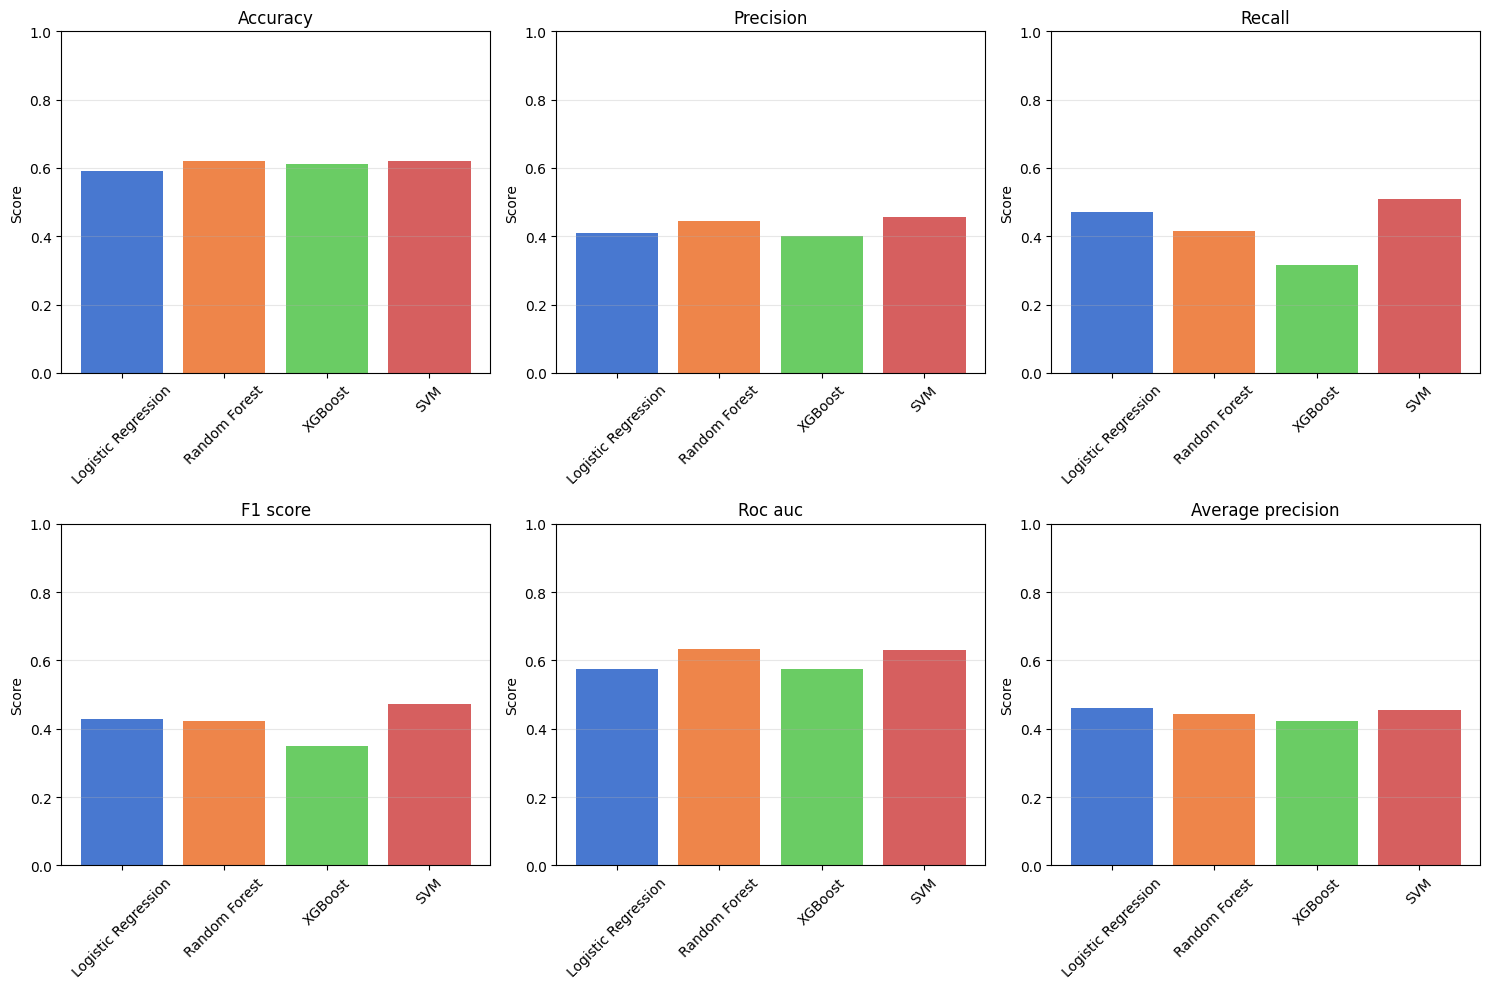

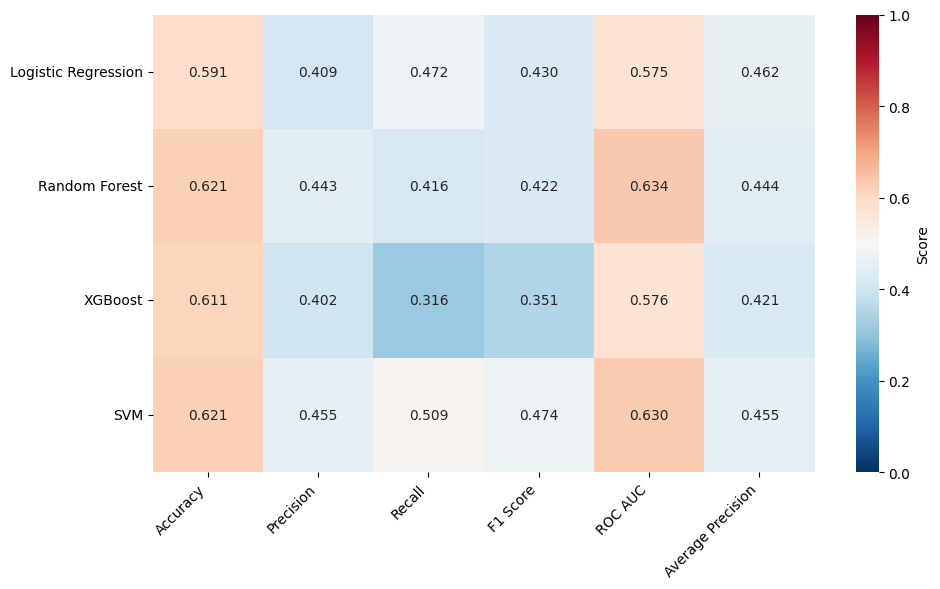

In [289]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import KNNImputer

# Define preprocessing pipelines
knn_features = ['das28_score', 'log_esr', 'log_crp_normalized', 'log_disease_duration']

preprocessor_parent_knn = ColumnTransformer(transformers=[
        ('cont', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), continuous_features),

        ('knn', Pipeline(steps=[
            ('scaler_before', StandardScaler()),
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler_after', StandardScaler())
            ]), knn_features),

        ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))]), binary_features),

        ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
], remainder='passthrough')

preprocessor_parent_knn.set_output(transform="pandas")

# FunctionTransformer to recalculate das28_change from imputed das28_score values
def recalculate_das28_change(df):
    df = df.copy()
    
    # Find the das28_score column (it's in the 'mice' transformer output)
    das28_col = [col for col in df.columns if 'das28_score' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]
    
    if das28_col and patient_id_col:
        das28_col = das28_col[0]
        patient_id_col = patient_id_col[0]
        
        # Recalculate das28_change from the newly imputed das28_score values
        df['das28_change'] = df.groupby(patient_id_col)[das28_col].diff().fillna(0)
        
        # Drop patient_id as it's not needed for the model
        df = df.drop(columns=[patient_id_col])
    
    return df

preprocessor_baseline = Pipeline(steps=[
    ('preprocessor_parent', preprocessor_parent_knn),
    ('recalc_das28', FunctionTransformer(recalculate_das28_change, validate=False)), 
    ('final_scaler', StandardScaler())
])

# Define baseline classifiers with optimized hyperparameters
baseline_classifiers = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', LogisticRegression(max_iter=1000,
                                          class_weight='balanced',
                                          random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', RandomForestClassifier(max_depth=5,
                                              min_samples_split=5, 
                                              min_samples_leaf=2, 
                                              class_weight='balanced', 
                                              random_state=42, 
                                              n_jobs=-1))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', XGBClassifier(max_depth=5,
                                     scale_pos_weight=(y == 0).sum() / (y == 1).sum(), 
                                     random_state=42, 
                                     eval_metric='logloss', 
                                     n_jobs=-1))
    ]),

    'SVM': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', SVC(class_weight='balanced', 
                           probability=True, 
                           random_state=42))
    ])
}

# Run cross-validation and collect results
cv_results = {}

for clf_name, clf_template in baseline_classifiers.items():
    cv_results[clf_name] = {
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'ROC AUC': [],
        'Average Precision': []
    }
    
    for train_idx, test_idx in stratified_group_kfold.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        clf = clone(clf_template)
        clf.fit(X_train, y_train)
        y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)[:, 1]
        
        cv_results[clf_name]['Accuracy'].append(accuracy_score(y_test, y_pred))
        cv_results[clf_name]['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
        cv_results[clf_name]['Recall'].append(recall_score(y_test, y_pred, zero_division=0))
        cv_results[clf_name]['F1 Score'].append(f1_score(y_test, y_pred, zero_division=0))
        cv_results[clf_name]['ROC AUC'].append(roc_auc_score(y_test, y_pred_proba))
        cv_results[clf_name]['Average Precision'].append(average_precision_score(y_test, y_pred_proba))

# Display results
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Average Precision']
results_df = pd.DataFrame({clf: {m: f"{np.mean(s):.3f} ± {np.std(s):.3f}" for m, s in cv_results[clf].items()} for clf in cv_results}).T
print("\n" + "="*115 + "\nBASELINE CLASSIFIER COMPARISON\n" + "="*115)
print(results_df.to_string())
print("="*115 + "\n")

# Visualizations
results_numeric = pd.DataFrame({m: [np.mean(cv_results[c][m]) for c in baseline_classifiers] for m in metric_names}, index=baseline_classifiers.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, metric in enumerate(metric_names):
    ax = axes.flatten()[idx]
    values = results_numeric[metric]
    ax.bar(range(len(values)), values, color=sns.color_palette('muted', len(values)))
    ax.set(xticks=range(len(values)), xticklabels=baseline_classifiers.keys(), ylabel='Score', title=metric.capitalize(), ylim=[0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
# plt.suptitle('Baseline Classifier Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(results_numeric, annot=True, fmt='.3f', cmap='RdBu_r', cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
# plt.title('Baseline Classifier - Metrics Heatmap', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Logistic Regression
Experiment 1.1
Feature selection method: SelectfromModel  
Solver: saga  
L1 regularization


In [265]:
selector_lr = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='saga',
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )
 )

model_lr = LogisticRegression(
   
    solver='saga',
    max_iter=5000,
    random_state=42
)


model_pipeline_lr = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', selector_lr),
    ('classifier', model_lr)
 ])


param_grid_lr = {
    'selector__estimator__C': [0.01, 0.05, 0.1, 1],
    'selector__threshold': ['median', 'mean', '1.25*median', '0.75*median'],
    'classifier__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
 }

grid_lr = GridSearchCV(
    estimator=model_pipeline_lr,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
 )

grid_lr.fit(X, y, groups=groups)

print("Best params:", grid_lr.best_params_)
print(f"Best CV score: {grid_lr.best_score_:.3f}")

best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.25, 'selector__estimator__C': 1, 'selector__threshold': 'mean'}
Best CV score: 0.704


In [266]:
y_prob_saga = cross_val_predict(
    best_lr, X, y, 
    cv=stratified_group_kfold, 
    groups=groups, 
    method='predict_proba'
)[:, 1]

# 2. Print the NEW distribution limits
print("--- SAGA Probability Distribution ---")
print(f"Maximum Probability: {np.max(y_prob_saga):.4f}")
print(f"Minimum Probability: {np.min(y_prob_saga):.4f}")
print(f"Average Probability: {np.mean(y_prob_saga):.4f}\n")

# 3. Let scikit-learn test every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_saga)

# Calculate the F1 score for every single threshold
# (Adding 1e-10 prevents 'divide by zero' errors)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find the exact index of the highest F1 score, and grab that threshold
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"*** Mathematically Optimal Threshold Found: {optimal_threshold:.4f} ***\n")

--- SAGA Probability Distribution ---
Maximum Probability: 0.6568
Minimum Probability: 0.3479
Average Probability: 0.4921

*** Mathematically Optimal Threshold Found: 0.4738 ***



In [247]:
y_prob_lr = cross_val_predict(best_lr, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

y_threshold_lr = 0.4941  # Default threshold
y_pred_lr = (y_prob_lr >= y_threshold_lr).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_lr):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr):.2f}")
print("="*60)


LOGISTIC REGRESSION - RESULTS
              precision    recall  f1-score   support

           0       0.77      0.57      0.66       263
           1       0.43      0.65      0.52       130

    accuracy                           0.60       393
   macro avg       0.60      0.61      0.59       393
weighted avg       0.66      0.60      0.61       393

accuracy_score: 0.60
ROC AUC: 0.68


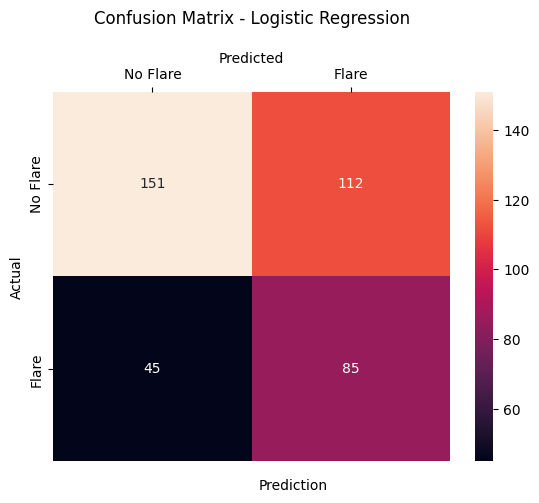

In [248]:
cm = confusion_matrix(y, y_pred_lr)

sns.heatmap(cm, 
            annot=True, 
            fmt='g',
            xticklabels=['No Flare', 'Flare'],
            yticklabels=['No Flare', 'Flare'])

plt.ylabel('Actual', fontsize=10)
plt.title('Confusion Matrix - Logistic Regression', fontsize=12, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Predicted', fontsize=10)
plt.gca().xaxis.tick_top()
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=10)
plt.show()


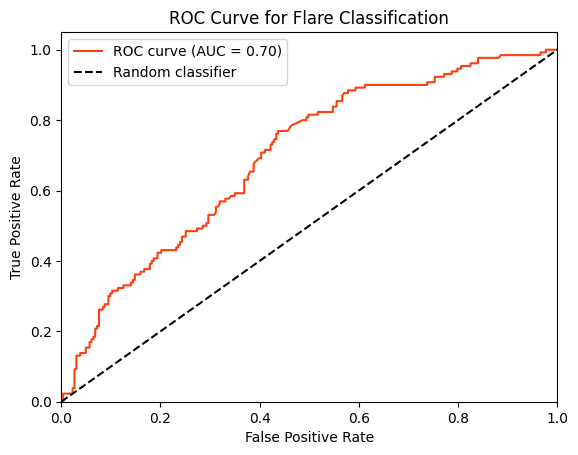

In [92]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_lr)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

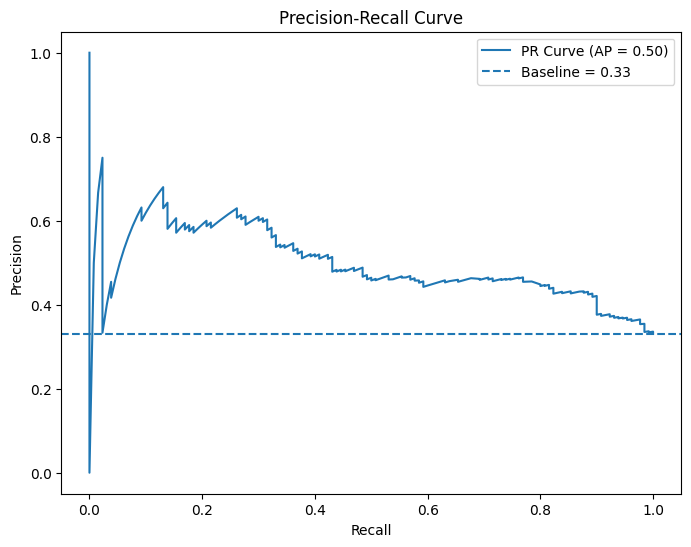

In [93]:
precision, recall, thresholds_pr = precision_recall_curve(y, y_prob_lr)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y, y_prob_lr)
baseline = y.mean()
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.axhline(y=baseline, linestyle='--', label=f'Baseline = {baseline:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

#### Experiment 1.2 Logistic Regression
Feature selection method: RFE

In [ ]:
selector_lr_rfe= RFE(
    estimator=LogisticRegression(
        l1_ratio=0,
        solver='saga',
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
        random_state=42 
),
    n_features_to_select=4,
    step=1
)

model_lr_rfe = LogisticRegression(
    l1_ratio=0,                     
    solver='saga',
    max_iter=5000,
    random_state=42
)

model_pipeline_lr_rfe = Pipeline(steps=[
    ('preprocessor_rfe', clone(preprocessor_baseline)),
    ('selector_lr_rfe', selector_lr_rfe),
    ('classifier_rfe', model_lr_rfe)
])


param_grid_lr = {
    'selector_lr_rfe__estimator__C': [0.01, 0.05, 0.1, 0.5, 1],
    'selector_lr_rfe__n_features_to_select': [3, 5, 8, 10],

    'classifier_rfe__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier_rfe__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier_rfe__class_weight': ['balanced', None],
  
 }

grid_lr_rfe = GridSearchCV(
    estimator=model_pipeline_lr_rfe,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_lr_rfe.fit(X, y, groups=groups)

print("Best params:", grid_lr_rfe.best_params_)
print("Best CV score:", grid_lr_rfe.best_score_)

best_lr_rfe = grid_lr_rfe.best_estimator_

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Best params: {'classifier_rfe__C': 1, 'classifier_rfe__class_weight': None, 'classifier_rfe__l1_ratio': 1, 'selector_lr_rfe__estimator__C': 0.01, 'selector_lr_rfe__n_features_to_select': 3}
Best CV score: 0.7059508805444945


In [ ]:
# 1. Generate Probabilities from the RFE Champion
y_prob__lr_rfe = cross_val_predict(best_lr_rfe, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

print("--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob__lr_rfe):.4f} | Min Prob: {np.min(y_prob__lr_rfe):.4f} | Avg: {np.mean(y_prob__lr_rfe):.4f}\n")

# 2. Find Optimal Threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y, y_prob__lr_rfe)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_rfe = thresholds[np.argmax(f1_scores)]
print(f"*** Optimal Threshold (Max F1) for RFE Model: {optimal_threshold_rfe:.4f} ***\n")

--- 1. Probability Distribution ---
Max Prob: 0.9274 | Min Prob: 0.0574 | Avg: 0.3299

*** Optimal Threshold (Max F1) for RFE Model: 0.2909 ***



In [ ]:
y_threshold__lr = 0.33
y_pred__lr_rfe = (y_prob__lr_rfe >= y_threshold__lr).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RFE RESULTS")
print("="*60)
print(classification_report(y, y_pred__lr_rfe, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred__lr_rfe):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob__lr_rfe):.2f}")
print("="*60)


LOGISTIC REGRESSION - RFE RESULTS
              precision    recall  f1-score   support

           0       0.80      0.60      0.69       263
           1       0.47      0.70      0.56       130

    accuracy                           0.64       393
   macro avg       0.63      0.65      0.62       393
weighted avg       0.69      0.64      0.65       393

accuracy_score: 0.64
ROC AUC: 0.70


### Experiment 1.3 Logistic Regression
Feature selection method: Mutual information

In [ ]:
selector_lr_mi = SelectKBest(mutual_info_classif, k=5)

model_lr_mi = LogisticRegression(
    l1_ratio=0,
    solver='saga',
    max_iter=5000,
    random_state=42
)

model_pipeline_lr_mi = Pipeline(steps=[
    ('preprocessor_mi', clone(preprocessor_baseline)),  
    ('selector_lr_mi', selector_lr_mi),
    ('classifier_mi', model_lr_mi)
])

param_grid_lr_mi = {
    'selector_lr_mi__k': [3, 5, 8, 10, 15],
    'classifier_mi__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier_mi__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier_mi__class_weight': ['balanced', None],
}

grid_lr_mi = GridSearchCV(
    estimator=model_pipeline_lr_mi, 
    param_grid=param_grid_lr_mi,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)   
grid_lr_mi.fit(X, y, groups=groups)
print("Best params:", grid_lr_mi.best_params_)
print(f"Best CV score: {grid_lr_mi.best_score_:.3f}")
best_lr_mi = grid_lr_mi.best_estimator_

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best params: {'classifier_mi__C': 0.01, 'classifier_mi__class_weight': None, 'classifier_mi__l1_ratio': 0.25, 'selector_lr_mi__k': 15}
Best CV score: 0.702


In [103]:
# 1. Generate the raw probabilities from the MI model
y_prob_mi = cross_val_predict(
    best_lr_mi, X, y, 
    cv=stratified_group_kfold, 
    groups=groups, 
    method='predict_proba'
)[:, 1]

# 2. Print the probability distribution
print("--- MI Probability Distribution ---")
print(f"Maximum Probability: {np.max(y_prob_mi):.4f}")
print(f"Minimum Probability: {np.min(y_prob_mi):.4f}")
print(f"Average Probability: {np.mean(y_prob_mi):.4f}\n")

# 3. Let scikit-learn test every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_mi)

# Calculate the F1 score for every single threshold
# (Adding 1e-10 prevents 'divide by zero' errors)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find the exact index of the highest F1 score, and grab that threshold
best_idx = np.argmax(f1_scores)
optimal_threshold_mi = thresholds[best_idx]

print(f"*** Mathematically Optimal Threshold Found: {optimal_threshold_mi:.4f} ***\n")


--- MI Probability Distribution ---
Maximum Probability: 0.4653
Minimum Probability: 0.2418
Average Probability: 0.3310

*** Mathematically Optimal Threshold Found: 0.3215 ***



In [ ]:
y_pred_lr_mi = cross_val_predict(best_lr_mi, X, y, cv=stratified_group_kfold, groups=groups, method='predict')
y_prob_lr_mi = cross_val_predict(best_lr_mi, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

# Use optimal threshold for predictions
y_pred_lr_mi_optimal = (y_prob_lr_mi >= 0.4931).astype(int)

print("\n" + "="*60)
print("LOGISTIC REGRESSION - MI RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr_mi_optimal, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_lr_mi_optimal):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr_mi):.2f}")
print("="*60)



LOGISTIC REGRESSION - MI RESULTS
              precision    recall  f1-score   support

           0       0.87      0.42      0.57       263
           1       0.43      0.88      0.57       130

    accuracy                           0.57       393
   macro avg       0.65      0.65      0.57       393
weighted avg       0.73      0.57      0.57       393

accuracy_score: 0.57
ROC AUC: 0.68


#### Random Forest
Experiment 2.1

In [109]:
model_rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('classifier', model_rf)
])

param_grid_rf ={
    'classifier__n_estimators': [ 100,200, 300, 400],
    'classifier__max_depth': [4, 6, 8, 10, None],
    'classifier__min_samples_leaf': [1, 2, 3, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']

}

grid_rf = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y, groups=groups)
print("Best params:", grid_rf.best_params_)
print(f"Best CV score: {grid_rf.best_score_:.3f}")
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 640 candidates, totalling 3200 fits
Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 400}
Best CV score: 0.641


In [110]:
y_prob_rf = cross_val_predict(best_rf, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

print("--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob_rf):.4f} | Min Prob: {np.min(y_prob_rf):.4f} | Avg: {np.mean(y_prob_rf):.4f}\n")

# 2. Find Optimal Threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_rf)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_rf = thresholds[np.argmax(f1_scores)]

print(f"--- 2. Clinical Metrics (Optimal Threshold: {optimal_threshold_rf:.4f}) ---")

--- 1. Probability Distribution ---
Max Prob: 0.7010 | Min Prob: 0.1397 | Avg: 0.4413

--- 2. Clinical Metrics (Optimal Threshold: 0.3790) ---


In [ ]:
y_pred_rf=cross_val_predict(best_rf, X, y, cv=stratified_group_kfold, groups=groups, method='predict')
y_prob_rf = cross_val_predict(best_rf, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

# Use optimal threshold for predictions
y_pred_rf_optimal = (y_prob_rf >= 0.4316).astype(int)

print("\n" + "="*60)
print("RANDOM FOREST - RF RESULTS")
print("="*60)
print(classification_report(y, y_pred_rf_optimal, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_rf_optimal):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_rf):.2f}")
print("="*60)


RANDOM FOREST - RF RESULTS
              precision    recall  f1-score   support

           0       0.81      0.42      0.55       263
           1       0.40      0.80      0.54       130

    accuracy                           0.54       393
   macro avg       0.61      0.61      0.54       393
weighted avg       0.68      0.54      0.55       393

accuracy_score: 0.54
ROC AUC: 0.63


### Experiment 2.2
Feature selection method: SelectFromModel


In [150]:
# Embedded feature selection with Random Forest importances
selector_rf = SelectFromModel(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        criterion='gini',
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    threshold='median'
)

model_rf_embedded = RandomForestClassifier(
    criterion='gini',
    random_state=42,
    n_jobs=1
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', selector_rf),
    ('classifier', model_rf_embedded)
])

param_grid_rf_embedded = {
    'selector__estimator__n_estimators': [100, 200],
    'selector__threshold': ['median', 'mean', '1.25*median', '0.75*median'],
    'selector__estimator__max_depth': [5, 10],
    
    'classifier__n_estimators': [150, 200, 350],
    'classifier__max_depth': [4, 5, 8, None],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}


grid_rf_embedded = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf_embedded,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_rf_embedded.fit(X, y, groups=groups)

print("Best params:", grid_rf_embedded.best_params_)
print("Best CV score:", grid_rf_embedded.best_score_)

best_rf_embedded = grid_rf_embedded.best_estimator_

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits
Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 350, 'selector__estimator__max_depth': 10, 'selector__estimator__n_estimators': 100, 'selector__threshold': 'mean'}
Best CV score: 0.652467877389503


In [151]:
y_prob_rf_embedded= cross_val_predict(best_rf_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

print("--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob_rf_embedded):.4f} | Min Prob: {np.min(y_prob_rf_embedded):.4f} | Avg: {np.mean(y_prob_rf_embedded):.4f}\n")

# 2. Find Optimal Threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_rf_embedded)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_rf_embedded = thresholds[np.argmax(f1_scores)]

print(f"--- 2. Clinical Metrics (Optimal Threshold: {optimal_threshold_rf_embedded:.4f}) ---")

--- 1. Probability Distribution ---
Max Prob: 0.7309 | Min Prob: 0.0690 | Avg: 0.4328

--- 2. Clinical Metrics (Optimal Threshold: 0.2950) ---


In [156]:
y_prob_rf_embedded = cross_val_predict(best_rf_embedded,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict_proba')[:, 1]

y_pred_default = (y_prob_rf_embedded >= 0.43).astype(int)

print(classification_report(y, y_pred_default))
print(f"Accuracy: {accuracy_score(y, y_pred_default):.2f}")

roc_auc = roc_auc_score(y, y_prob_rf_embedded)
print(f"ROC AUC: {roc_auc:.2f}")

              precision    recall  f1-score   support

           0       0.78      0.57      0.65       263
           1       0.43      0.67      0.53       130

    accuracy                           0.60       393
   macro avg       0.60      0.62      0.59       393
weighted avg       0.66      0.60      0.61       393

Accuracy: 0.60
ROC AUC: 0.64


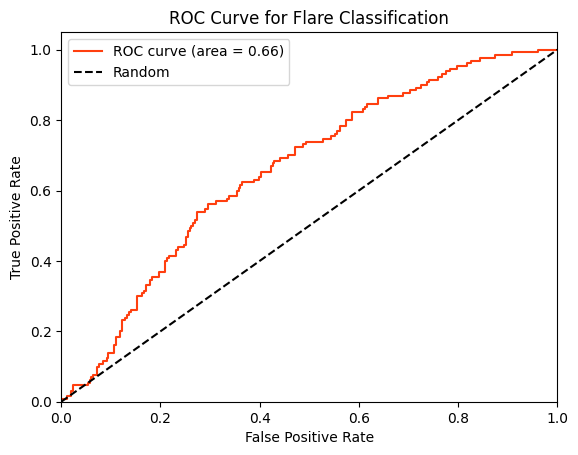

In [200]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_rf_embedded)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

#### Experiment 3.1 XGBoost
No feature selection method

In [117]:
model_xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    n_jobs=1
    
)


model_pipeline_xgb = Pipeline(steps = [
    ('preprocessor', clone(preprocessor_baseline)),
    ('classifier', model_xgb)
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_child_weight': [2, 4, 6],
    'classifier__subsample': [0.6, 0.8],        
    'classifier__colsample_bytree': [0.6, 0.8],    
    'classifier__scale_pos_weight': [1.5, 2.02, 2.5]
}

grid_xgb = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X, y, groups=groups)

print("Best params:", grid_xgb.best_params_)
print("Best CV score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_


Fitting 5 folds for each of 972 candidates, totalling 4860 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1.5, 'classifier__subsample': 0.6}
Best CV score: 0.6671680787631441


In [118]:
y_prob_xgboost = cross_val_predict(best_xgb, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

print("--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob_xgboost):.4f} | Min Prob: {np.min(y_prob_xgboost):.4f} | Avg: {np.mean(y_prob_xgboost):.4f}\n")

# 2. Find Optimal Threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_xgboost)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_xgboost = thresholds[np.argmax(f1_scores)]

print(f"--- 2. Clinical Metrics (Optimal Threshold: {optimal_threshold_xgboost:.4f}) ---")

--- 1. Probability Distribution ---
Max Prob: 0.7096 | Min Prob: 0.1548 | Avg: 0.4028

--- 2. Clinical Metrics (Optimal Threshold: 0.3259) ---


In [ ]:
y_prob_xgb = cross_val_predict(best_xgb, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.4731).astype(int)

print("\n" + "="*60)
print("XGBOOST - RESULTS")
print("="*60)
print(classification_report(y, y_pred_xgb, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_xgb):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_xgb):.2f}")
print("="*60)


XGBOOST - RESULTS
              precision    recall  f1-score   support

           0       0.77      0.59      0.67       263
           1       0.44      0.65      0.52       130

    accuracy                           0.61       393
   macro avg       0.60      0.62      0.59       393
weighted avg       0.66      0.61      0.62       393

accuracy_score: 0.61
ROC AUC: 0.66


### Experiment 3.2 - XGBoost 
Feature selection method: RFE

In [127]:
selector_xgb = RFE(
    estimator=XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        eval_metric='auc',
        n_jobs=1
    ),
    n_features_to_select=10
)

model_xgb_embedded = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    n_jobs=1
)

model_pipeline_xgb_embedded = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', selector_xgb),
    ('classifier', model_xgb_embedded)
])

param_grid_xgb_embedded = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_child_weight': [2, 4, 6],
    'classifier__subsample': [0.6, 0.8],        
    'classifier__colsample_bytree': [0.6, 0.8],    
    'classifier__scale_pos_weight': [1.5, 2.02, 2.5]
}

grid_xgb_embedded = GridSearchCV(
    estimator=model_pipeline_xgb_embedded,
    param_grid=param_grid_xgb_embedded,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1   
)

grid_xgb_embedded.fit(X, y, groups=groups)  
print("Best params:", grid_xgb_embedded.best_params_)
print("Best CV score:", grid_xgb_embedded.best_score_)
best_xgb_embedded = grid_xgb_embedded.best_estimator_


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1.5, 'classifier__subsample': 0.8}
Best CV score: 0.6703497781581962


In [128]:
y_prob_xgboost_embedded = cross_val_predict(best_xgb_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

print("--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob_xgboost_embedded):.4f} | Min Prob: {np.min(y_prob_xgboost_embedded):.4f} | Avg: {np.mean(y_prob_xgboost_embedded):.4f}\n")

# 2. Find Optimal Threshold (Maximizing F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_xgboost_embedded)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_xgboost = thresholds[np.argmax(f1_scores)]

print(f"--- 2. Clinical Metrics (Optimal Threshold: {optimal_threshold_xgboost:.4f}) ---")


--- 1. Probability Distribution ---
Max Prob: 0.6974 | Min Prob: 0.1268 | Avg: 0.4042

--- 2. Clinical Metrics (Optimal Threshold: 0.3477) ---


In [ ]:
y_prob_xgboost_embedded = cross_val_predict(best_xgb_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]
y_pred_xgb = (y_prob_xgboost_embedded >= 0.48).astype(int)

print("\n" + "="*60)
print("XGBOOST - RESULTS")
print("="*60)
print(classification_report(y, y_pred_xgb, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_xgb):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_xgboost_embedded):.2f}")
print("="*60)


XGBOOST - RESULTS
              precision    recall  f1-score   support

           0       0.79      0.58      0.67       263
           1       0.45      0.69      0.54       130

    accuracy                           0.62       393
   macro avg       0.62      0.64      0.61       393
weighted avg       0.68      0.62      0.63       393

accuracy_score: 0.62
ROC AUC: 0.67


### SVM

classifiers decision boundaries subplots -> visualization


In [ ]:

from sklearn.feature_selection import SelectKBest, f_classif

# 1. Base Model Setup
model_svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

# 2. Pipeline (Now explicitly includes Feature Selection to protect the distance math!)
model_pipeline_svm = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', model_svm)
])

# 3. The Targeted Grid (Added 'selector__k' to test different numbers of dimensions)
param_grid_svm = [
    {
        'selector__k': [3, 5, 7, 10, 'all'], # Test small feature spaces, plus 'all'
        'classifier__kernel': ['linear'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': ['balanced', None],
        'classifier__tol': [1e-4, 1e-3, 1e-2]
    },
    {
        'selector__k': [3, 5, 7, 10], # RBF almost always needs dimensionality reduction
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'classifier__class_weight': ['balanced', None],
        'classifier__tol': [0.0001, 0.001]
    },
    {
        'selector__k': [3, 5, 7, 10], # Poly also suffers in high dimensions
        'classifier__kernel': ['poly'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__degree': [2, 3, 4],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        'classifier__class_weight': ['balanced', None],
    }
]

grid_svm = GridSearchCV(
    estimator=model_pipeline_svm,
    param_grid=param_grid_svm,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X, y, groups=groups)
print("Best params:", grid_svm.best_params_)
print(f"Best CV score: {grid_svm.best_score_:.3f}")
best_svm = grid_svm.best_estimator_


Fitting 5 folds for each of 934 candidates, totalling 4670 fits
Best params: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__degree': 3, 'classifier__gamma': 'auto', 'classifier__kernel': 'poly', 'selector__k': 3}
Best CV score: 0.720


In [144]:
# 5. Out-of-fold Evaluation
y_prob_svm = cross_val_predict(estimator=best_svm, X=X, y=y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]  

print("\n--- 1. Probability Distribution ---")
print(f"Max Prob: {np.max(y_prob_svm):.4f} | Min Prob: {np.min(y_prob_svm):.4f} | Avg: {np.mean(y_prob_svm):.4f}\n")

# 6. Optimal Threshold Calculation
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_svm)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_threshold_svm = thresholds[np.argmax(f1_scores)]

print(f"--- 2. Clinical Metrics (Optimal Threshold: {optimal_threshold_svm:.4f}) ---")



--- 1. Probability Distribution ---
Max Prob: 0.9962 | Min Prob: 0.0390 | Avg: 0.3328

--- 2. Clinical Metrics (Optimal Threshold: 0.3062) ---


In [ ]:
y_pred_svm = (y_prob_svm >= 0.3).astype(int) 

print("\n" + "="*60)
print("SVM - RESULTS")
print("="*60)
print(classification_report(y, y_pred_svm, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_svm):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_svm):.2f}")
print("="*60)


SVM - RESULTS
              precision    recall  f1-score   support

           0       0.79      0.67      0.73       263
           1       0.49      0.64      0.56       130

    accuracy                           0.66       393
   macro avg       0.64      0.66      0.64       393
weighted avg       0.69      0.66      0.67       393

accuracy_score: 0.66
ROC AUC: 0.69
